In [1]:
import numpy as np
import matplotlib.pyplot as plt
import astropy 
from scipy.stats import gaussian_kde
import astropy.units as u
from astropy.constants import M_sun
from astropy.constants import c
from astropy.constants import L_sun
import astropy.cosmology.units as cu
from astropy.cosmology import Planck18 as cosmo
from astropy.constants import L_sun
L_sun_eps = L_sun.cgs.value


/beegfs/general/kprofit/binary_tests/ic_gen/ics_single_bh_3_cgm_000.hdf5


(1480.0, 1520.0)

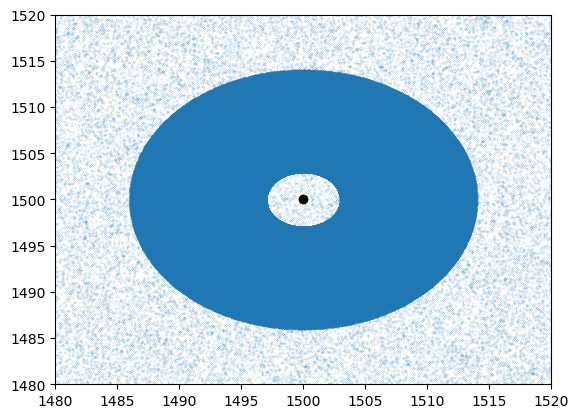

In [7]:
import sys
#sys.path.insert(0, '/mnt/home/skoudmani/for_kasar/python_scripts/')
sys.path.insert(0, '/soft/python3/usr/local/lib64/python3.9/site-packages') #import default cluster packages
sys.path.insert(0, '/beegfs/general/skoudmani/students/kasar/python/') #import custom packages
import read_snap_files as rsf
snapshot_path = '/beegfs/general/kprofit/binary_tests/ic_gen' 
snap_name = rsf.get_snap_filename(snapshot_path, 0, snap_prefix='ics_single_bh_3_cgm')
gas_coords = rsf.get_snap_data(snap_name, 0, 'Coordinates')
masses = rsf.get_snap_data(snap_name, 0, 'Masses')
BH_coords = rsf.get_snap_data(snap_name, 5, 'Coordinates')
BH_masses = rsf.get_snap_data(snap_name, 5, 'Masses')

x_coords = gas_coords[:,0]
y_coords = gas_coords[:,1] 
z_coords = gas_coords[:,2]



BH_x_coords = BH_coords[:,0]
BH_y_coords = BH_coords[:,1]

com = np.average(BH_coords,weights=BH_masses,axis=0) #calculate center of mass
gas_adj = gas_coords - com

print(snap_name)
plt.scatter(x_coords,y_coords, s=0.01)
plt.scatter(BH_x_coords,BH_y_coords, color = 'black')
plt.xlim(1480,1520)
plt.ylim(1480,1520)

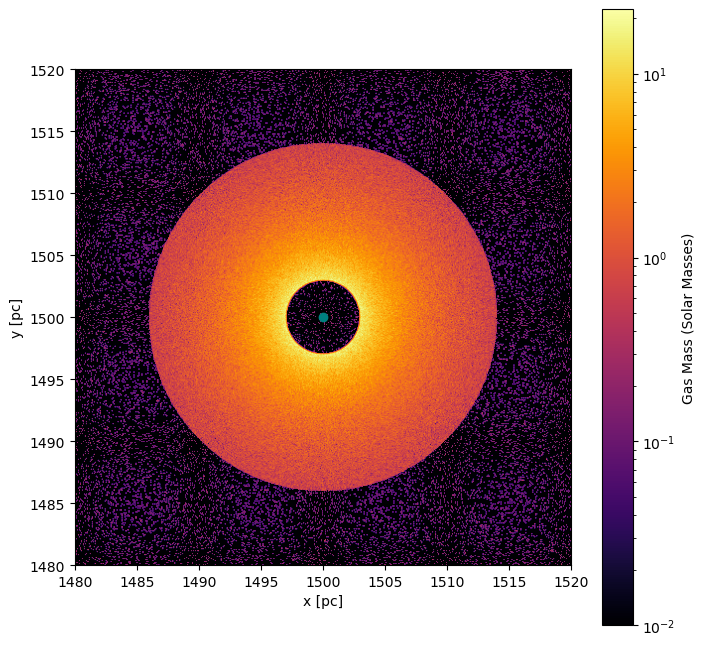

In [19]:
from matplotlib.colors import LogNorm

x_coords = gas_coords[:,0]
y_coords = gas_coords[:,1] 

BH_x_coords = BH_coords[:,0]
BH_y_coords = BH_coords[:,1]

nbins = 500
x_edges = np.linspace(1480,1520, nbins+1)
y_edges = np.linspace(1480,1520, nbins+1)

#weights = np.minimum(masses, 1.0)
#good = masses < 1

#image, _, _ = np.histogram2d(x_coords[good], y_coords[good], bins=[x_edges, y_edges], weights=masses[good])
image, _, _ = np.histogram2d(x_coords, y_coords, bins=[x_edges, y_edges], weights=masses)
image[image <= 0] = 1e-2  # Adjust this floor if needed

plt.figure(figsize=(8, 8))
plt.imshow(image.T, origin='lower', extent=[1480, 1520, 1480, 1520], cmap='inferno', norm=LogNorm())
plt.colorbar(label="Gas Mass (Solar Masses)")
plt.scatter(BH_x_coords,BH_y_coords, color = 'teal')

plt.xlabel("x [pc]")
plt.ylabel('y [pc]')

#plt.savefig("singleBH_2D_hist_mpl.png", bbox_inches="tight",dpi=800)
plt.show()


In [6]:
print(image.min(), image.max())
print(np.percentile(image[image > 0], [1,5,25,50,75,95,99]))

0.10201615493438934 1.0564656410731487e+35
[   4.00736462    5.909528   1000.         1000.         1000.
 1000.         1000.        ]


In [7]:
print(masses.min(), masses.max())
print(np.unique(masses[:20]))

0.0 3.107251885509262e+33
[0.10373672 0.10549071 0.10944637 0.1167012  0.11991553 0.12007677
 0.12685776 0.12726393 0.12811761 0.13033142 0.16186908 0.1648927
 0.20879439 0.22542057 0.24147946 0.24402275 0.25174503 0.27111675
 0.2779947  0.32528924]


In [40]:
print("Image min:", image.min())
print("Image max:", image.max())
print("Nonzero min:", image[image > 0].min())
print("Median:", np.median(image[image > 0]))
print("99th percentile:", np.percentile(image[image > 0], 99))
print("Fraction empty:", np.mean(image == 0))

Image min: 1e-09
Image max: 1.0564656410731487e+35
Nonzero min: 1e-09
Median: 1.2813417458243506
99th percentile: 9.557437854193893
Fraction empty: 0.0


In [42]:
print(masses.dtype)
print(masses.shape)
print(masses[:10])
print(np.percentile(masses, [0, 50, 90, 99, 99.9, 100]))

float64
(1033637,)
[0.20879439 0.1648927  0.12726393 0.32528924 0.16186908 0.27111675
 0.24402275 0.12685776 0.13033142 0.24147946]
[0.00000000e+00 1.64277170e-01 3.45239969e-01 4.59299921e-01
 4.74769788e-01 3.10725189e+33]


In [54]:
print(BH_masses)

[2000000.]


In [53]:
mask = masses > 1

print("Particles with mass > 1:", np.sum(mask))
print(masses[mask])

Particles with mass > 1: 289
[3.10725189e+33 3.10725189e+33 3.10725189e+33 3.10725189e+33
 3.10725189e+33 3.10725189e+33 3.10725189e+33 3.10725189e+33
 3.10725189e+33 3.10725189e+33 3.10725189e+33 3.10725189e+33
 3.10725189e+33 3.10725189e+33 3.10725189e+33 3.10725189e+33
 3.10725189e+33 3.10725189e+33 3.10725189e+33 3.10725189e+33
 3.10725189e+33 3.10725189e+33 3.10725189e+33 3.10725189e+33
 3.10725189e+33 3.10725189e+33 3.10725189e+33 3.10725189e+33
 3.10725189e+33 3.10725189e+33 3.10725189e+33 3.10725189e+33
 3.10725189e+33 3.10725189e+33 3.10725189e+33 3.10725189e+33
 3.10725189e+33 3.10725189e+33 3.10725189e+33 3.10725189e+33
 3.10725189e+33 3.10725189e+33 3.10725189e+33 3.10725189e+33
 3.10725189e+33 3.10725189e+33 3.10725189e+33 3.10725189e+33
 3.10725189e+33 3.10725189e+33 3.10725189e+33 3.10725189e+33
 3.10725189e+33 3.10725189e+33 3.10725189e+33 3.10725189e+33
 3.10725189e+33 3.10725189e+33 3.10725189e+33 3.10725189e+33
 3.10725189e+33 3.10725189e+33 3.10725189e+33 3.10725189